In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from linearmodels.iv import IV2SLS
from scipy.stats import gaussian_kde

In [6]:
# Parameters
n_population = 10000  # Full population size
n_sample = 2000  # Observed sample size
instrument_strength = 0.25  # Strength of the instrument's correlation with treatment uptake

def clinical_trial_model(p_treatment: float = 2., health_impact_treatment: float = None, health_impact_ability: float = None):
    # Generate true population data
    baseline_health = np.random.normal(0, 1, n_population)  # Unobserved baseline health factor
    if health_impact_treatment is None:
        health_impact_treatment = np.random.uniform(0.5, 5)  # 3
    if health_impact_ability is None:
        health_impact_ability = np.random.uniform(0.1, 1)  # 0.8
    
    # Instrument: distance to nearest treatment facility (affects treatment uptake but not health directly)
    distance_to_facility = np.clip(np.random.normal(10, 5, n_population), 1, 100)
    
    # Treatment uptake is influenced by baseline health and distance to the facility (the instrument)
    treatment_uptake = 1 + health_impact_ability * baseline_health - instrument_strength * distance_to_facility + np.random.normal(0, 1, n_population)
    treatment_uptake = (treatment_uptake > 0).astype(int)  # Binary treatment uptake (1 if treatment received, 0 otherwise)
    
    # Health outcome depends on treatment uptake and baseline health (baseline health is unobserved)
    true_health_outcomes = 50 + p_treatment * treatment_uptake + health_impact_treatment * baseline_health + np.random.normal(0, 2, n_population)
    true_health_outcomes[true_health_outcomes < 0] = 0  # Health outcomes cannot be negative
    
    # Create a participation probability based on baseline health
    participation_prob = np.clip(0.2 - 0.2 * baseline_health, 0, 1)
    participation = np.random.binomial(1, participation_prob, n_population)

    # Create observed sample (sample where individuals' health outcomes are observed)
    observed_indices = np.where(participation == 1)[0]
    _n_sample = min(n_sample, len(observed_indices))
    observed_sample_indices = np.random.choice(observed_indices, _n_sample, replace=False)
    
    # Create the observed sample data
    observed_data = pd.DataFrame({
        'treatment_uptake': treatment_uptake[observed_sample_indices],
        'distance_to_facility': distance_to_facility[observed_sample_indices],  # Instrument
        'true_health_outcomes': true_health_outcomes[observed_sample_indices],  # Actual health outcomes
        'baseline_health': baseline_health[observed_sample_indices]  # Unobserved baseline health
    })
    
    # Full population data (for reference)
    population_data = pd.DataFrame({
        'treatment_uptake': treatment_uptake,
        'distance_to_facility': distance_to_facility,  # Instrument
        'true_health_outcomes': true_health_outcomes,  # Actual health outcomes for the full population
        'participation': participation,  # Whether they are included in the observed sample
        'baseline_health': baseline_health  # Unobserved baseline health
    })
    return observed_data, population_data

In [7]:
np.random.seed(42)
true_param = 1.7
obs, pop = clinical_trial_model(true_param, health_impact_treatment=0.8, health_impact_ability=3)
print(obs.shape)

(2000, 4)


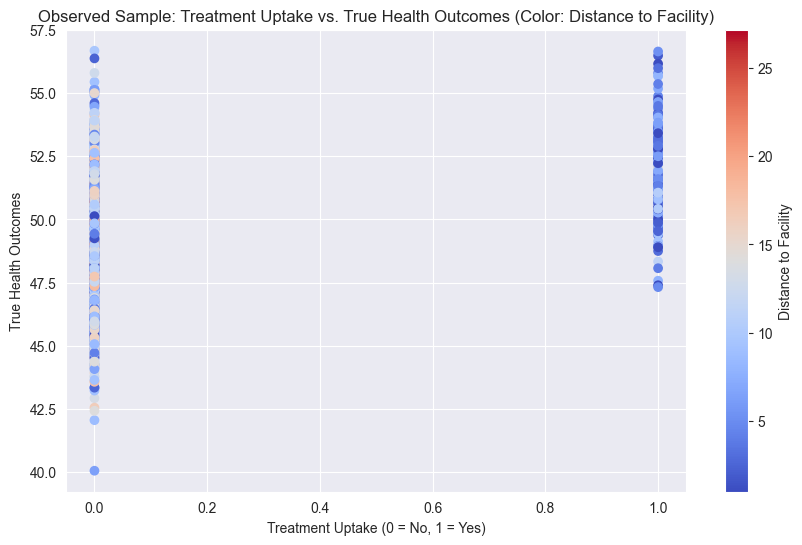

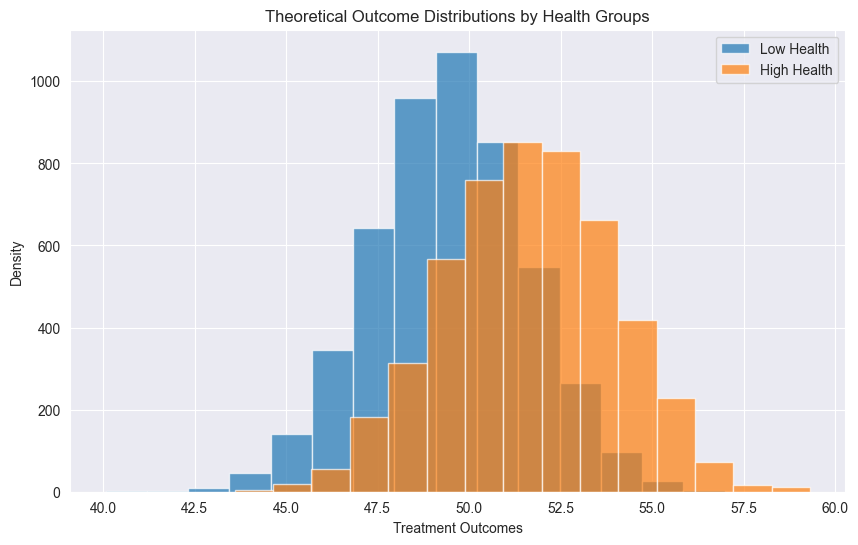

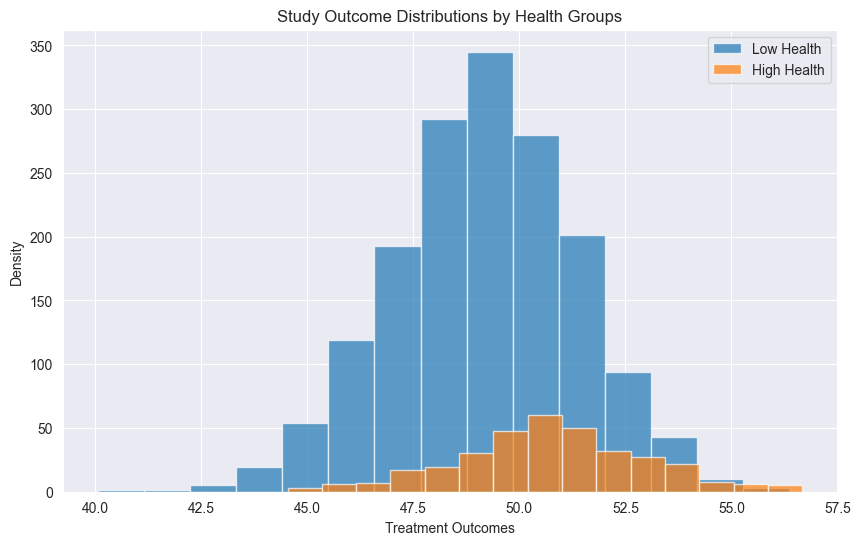

In [17]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(x=obs['treatment_uptake'], y=obs['true_health_outcomes'], c=obs['distance_to_facility'], cmap='coolwarm')
plt.title('Observed Sample: Treatment Uptake vs. True Health Outcomes (Color: Distance to Facility)')
plt.xlabel('Treatment Uptake (0 = No, 1 = Yes)')
plt.ylabel('True Health Outcomes')
plt.colorbar(scatter, label='Distance to Facility')
plt.show()

plt.figure(figsize=(10, 6))
plt.hist(pop.loc[pop['baseline_health']<0, 'true_health_outcomes'],
         bins=15, alpha=0.7, label="Low Health")
plt.hist(pop.loc[pop['baseline_health']>0, 'true_health_outcomes'],
         bins=15, alpha=0.7, label="High Health")
#plt.axvline(np.mean(low_health), color="blue", linestyle="dashed", linewidth=1, label="Mean Low Health")
#plt.axvline(np.mean(high_health), color="orange", linestyle="dashed", linewidth=1, label="Mean High Health")
plt.xlabel("Health Outcomes")
plt.ylabel("Density")
plt.title("Theoretical Outcome Distributions by Health Groups")
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
plt.hist(obs.loc[obs['baseline_health']<0, 'true_health_outcomes'],
         bins=15, alpha=0.7, label="Low Health")
plt.hist(obs.loc[obs['baseline_health']>0, 'true_health_outcomes'],
         bins=15, alpha=0.7, label="High Health")
#plt.axvline(np.mean(low_health), color="blue", linestyle="dashed", linewidth=1, label="Mean Low Health")
#plt.axvline(np.mean(high_health), color="orange", linestyle="dashed", linewidth=1, label="Mean High Health")
plt.xlabel("Health Outcomes")
plt.ylabel("Density")
plt.title("Study Outcome Distributions by Health Groups")
plt.legend()
plt.show()

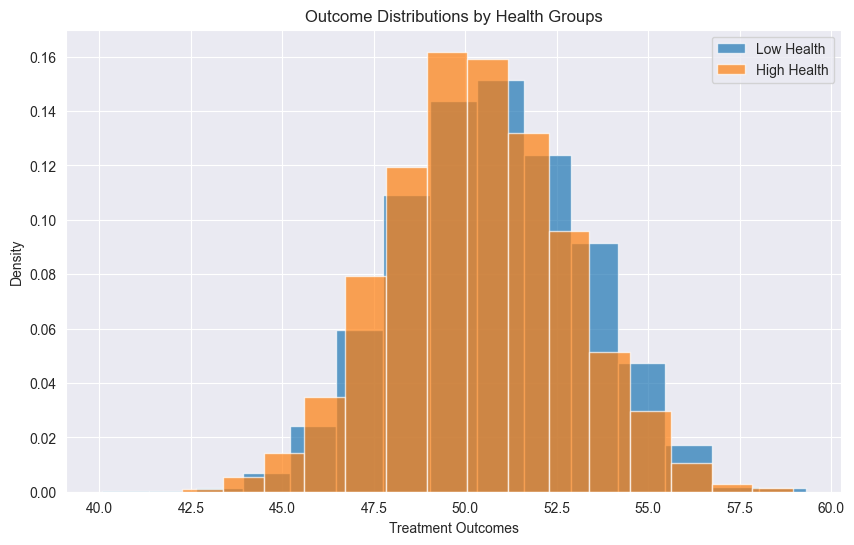

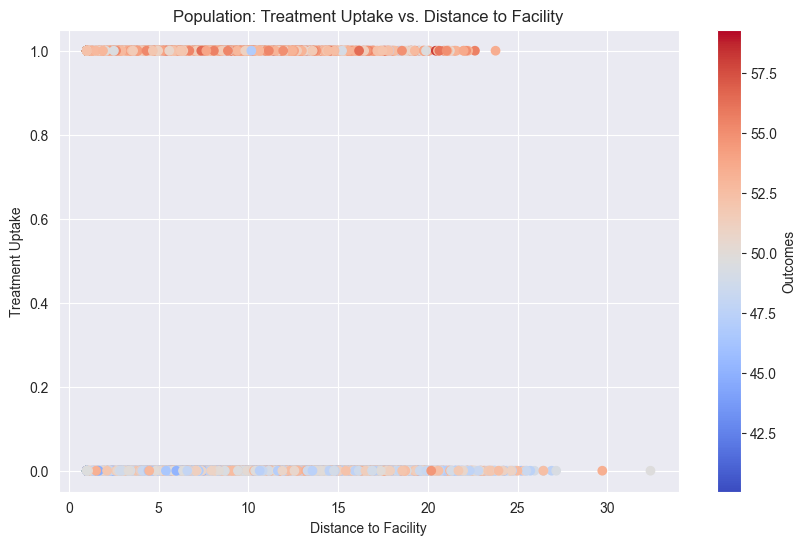

In [23]:
plt.figure(figsize=(10, 6))
plt.hist(pop.loc[pop['distance_to_facility']<pop['distance_to_facility'].mean(), 'true_health_outcomes'],
         bins=15, alpha=0.7, label="Low Health", density=True)
plt.hist(pop.loc[pop['distance_to_facility']>pop['distance_to_facility'].mean(), 'true_health_outcomes'],
         bins=15, alpha=0.7, label="High Health", density=True)
#plt.axvline(np.mean(low_health), color="blue", linestyle="dashed", linewidth=1, label="Mean Low Health")
#plt.axvline(np.mean(high_health), color="orange", linestyle="dashed", linewidth=1, label="Mean High Health")
plt.xlabel("Treatment Outcomes")
plt.ylabel("Density")
plt.title("Outcome Distributions by Health Groups")
plt.legend()
plt.show()

# plot treatment uptake against distance
plt.figure(figsize=(10, 6))
plt.scatter(x=pop['distance_to_facility'], y=pop['treatment_uptake'], c=pop['true_health_outcomes'], cmap='coolwarm')
plt.colorbar(label='Outcomes')
plt.xlabel('Distance to Facility')
plt.ylabel('Treatment Uptake')
plt.title('Population: Treatment Uptake vs. Distance to Facility')
plt.show()

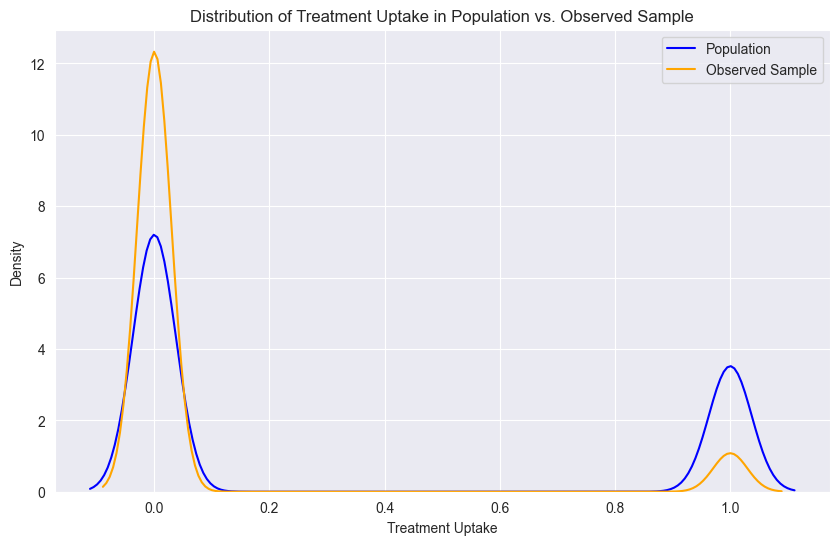

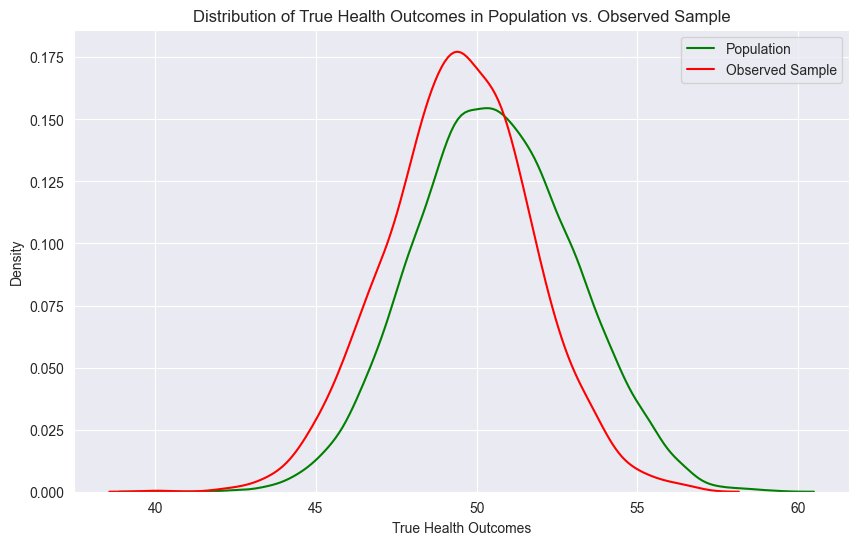

In [19]:
# Visualizing the distribution of treatment uptake in both the population and observed sample
plt.figure(figsize=(10, 6))
sns.kdeplot(pop['treatment_uptake'], label='Population', color='blue', bw_adjust=0.5)
sns.kdeplot(obs['treatment_uptake'], label='Observed Sample', color='orange', bw_adjust=0.5)
plt.title('Distribution of Treatment Uptake in Population vs. Observed Sample')
plt.xlabel('Treatment Uptake')
plt.ylabel('Density')
plt.legend()
plt.show()

# Visualizing the distribution of health outcomes in both the population and observed sample
plt.figure(figsize=(10, 6))
sns.kdeplot(pop['true_health_outcomes'], label='Population', color='green')
sns.kdeplot(obs['true_health_outcomes'], label='Observed Sample', color='red')
plt.title('Distribution of True Health Outcomes in Population vs. Observed Sample')
plt.xlabel('True Health Outcomes')
plt.ylabel('Density')
plt.legend()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx

# Step 1: Create a causal diagram (DAG)
G = nx.DiGraph()
# Add nodes
nodes = ["Health", "Treatment", "Outcome", "Proximity to Hospital"]
G.add_nodes_from(nodes)

# Add edges
edges = [
    ("Health", "Treatment"),
    ("Health", "Outcome"),
    ("Treatment", "Outcome"),
    ("Proximity to Hospital", "Treatment"),
]
G.add_edges_from(edges)

# Draw the DAG
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G, seed=42)
nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=3000,
    node_color="lightblue",
    font_size=10,
    font_weight="bold",
    edge_color="gray",
)
plt.title("Causal Diagram (DAG)")
plt.show()

# Step 2: Comparison chart (Naive vs IV vs Better Method)
methods = ["Naive", "Instrumental Variable (IV)", "Alternative (No IV)"]
bias_levels = [0.6, 0.2, 0.1]  # Hypothetical bias levels

plt.figure(figsize=(8, 5))
plt.bar(methods, bias_levels, color="skyblue")
plt.xlabel("Methods")
plt.ylabel("Bias Level (Lower is Better)")
plt.title("Comparison of Bias in Treatment Effect Estimation")
plt.ylim(0, 1)
plt.show()

In [ ]:
# Set up the IV model
obs['constant'] = 1.

ols_model = IV2SLS(
    dependent=obs['true_health_outcomes'], 
    exog=obs[['constant', 'treatment_uptake']], 
    endog=None, 
    instruments=None
)

# Fit the model
ols_results = ols_model.fit()

# Show OLS results
print(ols_results.summary)
ols_result = {
    'params': ols_results.params['treatment_uptake'],
    'CI': ols_results.conf_int().loc['treatment_uptake'].values
}

In [ ]:
# Set up the IV model
res_first = IV2SLS(
    dependent=obs['treatment_uptake'], 
    exog=obs[['constant', 'distance_to_facility']], 
    endog=None,
    instruments=None
)

# Fit the model
first_results = res_first.fit()

# Show results
print(first_results.summary)  # F-test should be at least 10

In [ ]:
# Set up the IV model
iv_model = IV2SLS(
    dependent=obs['true_health_outcomes'], 
    exog=obs[['constant']], 
    endog=obs[['treatment_uptake']],
    instruments=obs['distance_to_facility']
)

# Fit the model
iv_results = iv_model.fit() #cov_type="unadjusted")

# Show results, which include correct CIs
print(iv_results.summary)
iv_result = {
    'params': iv_results.params['treatment_uptake'],
    'CI': iv_results.conf_int().loc['treatment_uptake'].values
}

In [ ]:
ols_result, iv_result

# Use BayesFlow

In [ ]:
import bayesflow as bf
from bayesflow.networks import InvertibleNetwork, DeepSet
from bayesflow.amortizers import AmortizedPosterior
from bayesflow.trainers import Trainer

In [ ]:
posterior_samples_dict = {
    'instrument_observed': None,
    'no_instrument_observed': None,
}
param_names = ['treatment_uptake']

In [ ]:
instrument_observed = True

In [ ]:
def generative_model(n_samples: int = None, param_batch: np.ndarray = None):
    if param_batch is None:
        if n_samples is None:
            raise ValueError("Either n_samples or param_batch must be provided.")
        param_batch = np.random.uniform(0, 5, size=(n_samples, 1))
    
    # Initialize data array
    data = np.zeros((len(param_batch), n_sample, 3 if instrument_observed else 2))
    for i, param in enumerate(param_batch):
        # Generate data for the clinical model with the given parameter
        data_i, _ = clinical_trial_model(param[0])  # Only one parameter in the batch
        
        # Include instrument in data if observed, otherwise exclude it
        if instrument_observed:
            data_i = data_i[['true_health_outcomes', 'treatment_uptake', 'distance_to_facility']].values
        else:
            data_i = data_i[['true_health_outcomes', 'treatment_uptake']].values
            
        # Ensure data has the correct sample size, pad if necessary
        if data_i.shape[0] < n_sample:
            data_i = np.pad(data_i, ((0, n_sample - data_i.shape[0]), (0, 0)), mode='constant', constant_values=-0.1)
        
        data[i] = data_i  # Assign to batch data
    
    return {'sim_data': data, 'prior_draws': param_batch}


In [ ]:
summary_net = DeepSet(summary_dim=2)

inference_net = InvertibleNetwork(
    num_params=len(param_names),
    num_coupling_layers=3,
    permutation="learnable"  # todo: can be removed
)
amortizer = AmortizedPosterior(
    inference_net=inference_net,
    summary_net=summary_net,
)

In [ ]:
np.random.seed(42)
_sim_data = generative_model(1000)
prior_mean = _sim_data['prior_draws'].mean(axis=0)
prior_std = _sim_data['prior_draws'].std(axis=0)
x_mean = np.log1p(_sim_data['sim_data']).mean(axis=(0,1))  # todo: this changed
x_std = np.log1p(_sim_data['sim_data']).std(axis=(0,1))

In [ ]:
def configurator(forward_dict: dict) -> dict:
    # Extract data
    x = forward_dict["sim_data"]
    x = np.log1p(x)
    x = (x - x_mean) / x_std
    out_dict = {
        'summary_conditions': x.astype(np.float32)
    }

    # Extract params
    if 'parameters' in forward_dict.keys():
        forward_dict["prior_draws"] = forward_dict["parameters"]
    if 'prior_draws' in forward_dict.keys():
        params = forward_dict["prior_draws"]
        # normalize
        params = (params - prior_mean) / prior_std
        out_dict['parameters'] = params.astype(np.float32)
    return out_dict

In [ ]:
trainer = Trainer(
    amortizer=amortizer,
    configurator=configurator,
    generative_model=generative_model,
    checkpoint_path='amortizer_health_IV' if instrument_observed else 'amortizer_health',
)

In [ ]:
%%time
np.random.seed(42)
offline_data = generative_model(10000)
valid_data = generative_model(256)
prior_draws = valid_data['prior_draws']

In [ ]:
if trainer.checkpoint_path is None:
    history = trainer.train_offline(
        simulations_dict=offline_data,
        epochs=30,
        batch_size=128,
        early_stopping=True,
        validation_sims=valid_data
    )
else:
    trainer.load_pretrained_network()
    history = trainer.loss_history.get_plottable()

In [ ]:
bf.diagnostics.plot_losses(history['train_losses'], history['val_losses'], fig_size=(10, 6));

In [ ]:
posterior_samples = trainer.amortizer.sample(trainer.configurator(valid_data), n_samples=100)
posterior_samples = posterior_samples * prior_std + prior_mean

In [ ]:
bf.diagnostics.plot_sbc_ecdf(posterior_samples, prior_draws, difference=True, param_names=param_names);

In [ ]:
bf.diagnostics.plot_recovery(posterior_samples, prior_draws, param_names=param_names);

In [ ]:
bf.diagnostics.plot_z_score_contraction(posterior_samples, prior_draws, param_names=param_names);

## Sampled vs IV

In [ ]:
iv_params = np.zeros((valid_data['sim_data'].shape[0], 1))
if instrument_observed:
    for i, d in enumerate(valid_data['sim_data']):
        iv_temp = IV2SLS(
            dependent=d[:, 0],
            exog=obs[['constant']],
            endog=d[:, 1],
            instruments=d[:, 2],
        )
        iv_temp = iv_temp.fit()
        iv_params[i] = iv_temp.params['endog']

In [ ]:
ols_params = np.zeros((valid_data['sim_data'].shape[0], 1))
for i, d in enumerate(valid_data['sim_data']):
    ols_temp = IV2SLS(
        dependent=d[:, 0],
        exog=np.concatenate((obs[['constant']], d[:, 1][:, np.newaxis]), axis=1),
        endog=None,
        instruments=None,
    )
    ols_temp = ols_temp.fit()
    ols_params[i] = ols_temp.params['exog.1']

In [ ]:
posterior_samples = trainer.amortizer.sample(trainer.configurator(valid_data), n_samples=1000)
posterior_samples = posterior_samples * prior_std + prior_mean

In [ ]:
samples_all = np.concatenate((
    posterior_samples,
    np.repeat(iv_params, repeats=posterior_samples.shape[1], axis=1)[:, :, np.newaxis],
    np.repeat(ols_params, repeats=posterior_samples.shape[1], axis=1)[:, :, np.newaxis]
), axis=-1)

ground_truth = np.concatenate((valid_data['prior_draws'], valid_data['prior_draws'], valid_data['prior_draws']), axis=-1)

In [ ]:
bf.diagnostics.plot_recovery(samples_all, ground_truth, param_names=['Sampled', 'Instrumental Variables', 'Linear Regression']);

## Test Data

In [ ]:
if instrument_observed:
    test_data = {'sim_data': obs[['true_health_outcomes', 'treatment_uptake', 'distance_to_facility']].values[np.newaxis]}
else:
    test_data = {'sim_data': obs[['true_health_outcomes', 'treatment_uptake']].values[np.newaxis]}
    
# Generate posterior samples using the trainer's amortizer and configurator for the test data
posterior_samples = trainer.amortizer.sample(trainer.configurator(test_data), n_samples=1000)
posterior_samples = posterior_samples * prior_std + prior_mean

# Store posterior samples based on whether the instrument is observed
if instrument_observed:
    posterior_samples_dict['instrument_observed'] = posterior_samples.copy()
else:
    posterior_samples_dict['no_instrument_observed'] = posterior_samples.copy()

In [ ]:
fig = plt.figure(figsize=(4, 4))
plt.hist(posterior_samples, density=True, alpha=0.9, color="#8f2727", label='Posterior')
plt.hist(prior_draws, density=True, alpha=0.9, color="gray", label='Prior')

# Add reference lines for different estimates
plt.axvline(ols_result['params'], color='b', label='Biased')
plt.errorbar(ols_result['params'], 0.75, xerr=np.abs(ols_result['CI'][:, np.newaxis]-ols_result['params']), color='b')

plt.axvline(iv_result['params'], color='r', label='IV Estimate')
plt.errorbar(iv_result['params'], 0.5, xerr=np.abs(iv_result['CI'][:, np.newaxis]-iv_result['params']), color='r')

plt.axvline(true_param, color='g', label='True')

plt.legend()
plt.xlabel('Effect of Treatment')
plt.title(f'Estimated Effect of Treatment on Health Outcomes\n{"with Instruments Observed" if instrument_observed else ""}')
plt.show()

In [ ]:
if posterior_samples_dict['instrument_observed'] is not None and posterior_samples_dict['no_instrument_observed'] is not None:
    fig = plt.figure(figsize=(4, 4))
    x = np.linspace(0, 5, 1000)
    
    # KDE plot for posterior samples with observed instrument
    kde = gaussian_kde(posterior_samples_dict['instrument_observed'].flatten())
    plt.plot(x, kde(x), color='#8f2727', label='Posterior with Observed Instrument')
    
    # KDE plot for posterior samples without observed instrument
    kde_no = gaussian_kde(posterior_samples_dict['no_instrument_observed'].flatten())
    plt.plot(x, kde_no(x), color='#8f5727', label='Posterior')
    
    # Add reference lines for different estimates
    plt.axvline(ols_result['params'], color='b', label='Biased')
    plt.axvline(iv_result['params'], color='r', label='IV Estimate')
    plt.axvline(true_param, color='g', label='True')
    
    plt.legend(loc='lower left')
    plt.xlabel('Effect of Treatment')
    plt.title('Posterior Distributions of Treatment Effect on Health Outcomes')
    plt.show()